In [1]:
import numpy as np
import torch
import scanpy as sc
import anndata as ad
import os
import pandas as pd
from utils.preprocess import *
import os
import sys
    
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
import torchsde
from torchdyn.core import NeuralODE
from tqdm import tqdm
from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper
from simulate.simulate import *
from omegaconf import OmegaConf
from utils.hydra import *
from datasets.process import *
from scripts.run_model import *
import matplotlib.pyplot as plt
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
dic = {"path": sample_path,
       }

In [3]:
### SETTINGS ###

dataname = "path"
size = 2500
d = 2 #dummy dimension

project = "ffm-ipynb"
adata = process_fake_data(size, d, dic[dataname])
timepoints = sorted(adata.obs['timepoint'].unique().tolist())
tree = adata.uns['tree']

config = load_config()
OmegaConf.set_struct(config, False)
config.pc_dim = d
config.num_classes = adata.obs['cell_type'].nunique()

config.t0_index = 0
config.t1_index = 2
config.score_batch_size = 1024

In [4]:

config.metric = "cfm"
config.finsler.use = True
config.finsler.lamb = 30.0
config.dummy_kl_weight = 0.3

config.classifier_max_epochs = 500
config.metric_max_epochs = 2
config.flow_max_epochs = 2

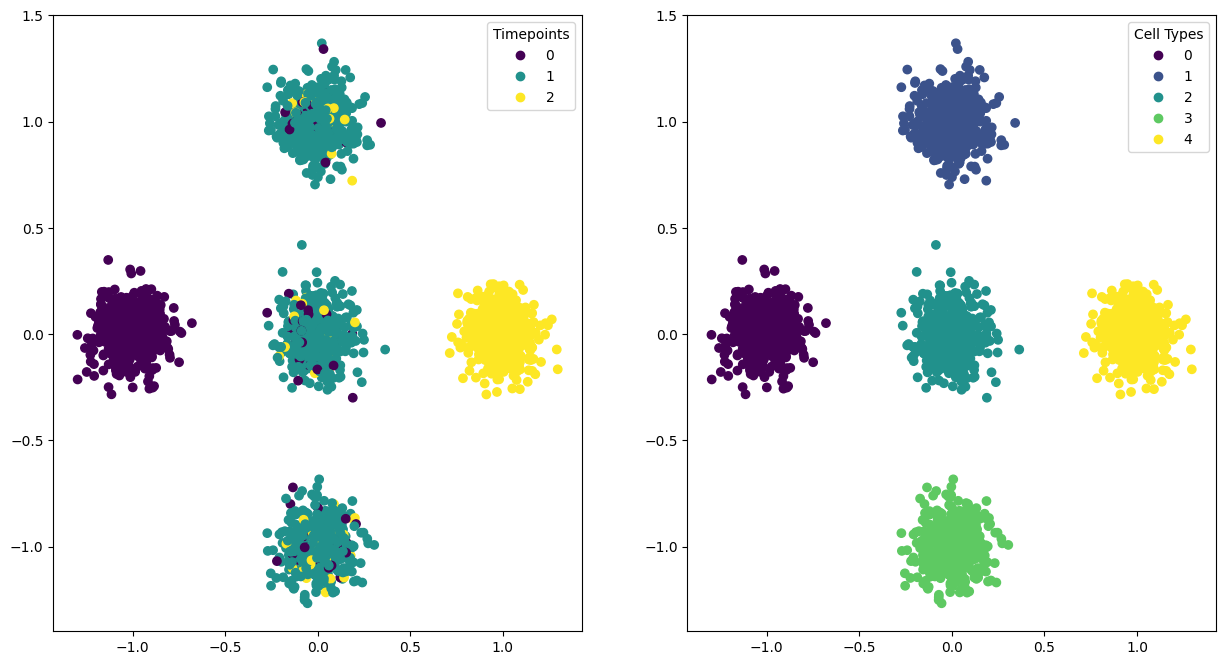

In [5]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()
fig, axs = plt.subplots(1, 2, figsize = (15, 8))
scatter0 = axs[0].scatter(samples[:,0], samples[:, 1], c=adata.obs['timepoint'].astype(int).tolist())
handles, labels = scatter0.legend_elements()
axs[0].legend(handles, labels, title="Timepoints")
scatter1 = axs[1].scatter(samples[:,0], samples[:, 1], c=adata.obs['cell_type_one_hot'].astype(int).tolist())
handles, labels = scatter1.legend_elements()
axs[1].legend(handles, labels, title="Cell Types")

plt.show()

In [6]:
t0, t1 = timepoints[config.t0_index], timepoints[config.t1_index]
adata = adata[(adata.obs['timepoint'] >= t0) & (adata.obs['timepoint'] <= t1)]
adata_train = adata[adata.obs['timepoint'].isin([t0, t1])]
print(t0, t1)

0 2


In [7]:
singleton_dataloader = build_singleton_dataloader(config, adata_train)
paired_dataloader = build_paired_dataloader(config, adata_train)

In [8]:

classifier_model, metric_model, embed_model, flow_model = run_full_model(config=config,
                                                                         project=project,
                                                                         singleton_dataloader=singleton_dataloader,
                                                                         paired_dataloader=paired_dataloader,
                                                                         timepoints=timepoints,
                                                                         tree=tree)

DEBUG: no fisher rao
DEBUG: trying dumb first loss as scaling for embed
Running phase classifier:.......


wandb: Currently logged in as: az831 (az831-new-york-genome-center) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name           | Type           | Params | Mode 
----------------------------------------------------

epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇█████
train_ce,█▇▆▆▅▅▄▄▄▄▄▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_kl,▁▁▁▂▂▂▂▂▂▃▄▅▅▆▆▆▆▇▇▇▇███████████████████
train_loss_classifier,██▇▇▇▄▄▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▁▁▂▂▂▂▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇████
epoch,499
train_ce,0.24564
train_kl,0.9261
train_loss_classifier,0.52347
trainer/global_step,499


Running phase metric:.......


...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type           | Params | Mode 
--------------------------------------------------------
0 | embed_net    | SimpleEmbedNet | 159 K  | train
1 | geo_net      | SinNet         | 151 K  | train
2 | metric_model | FinslerCFM     | 226    | eval 
  | other params | n/a            | 50     | n/a  
--------------------------------------------------------
310 K     Trainable params
226       Non-trainable params
311 K     Total params
1.245     Total estimated

epoch,▁▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇████
train_loss_embed,▁▁▂▂▂▁▂▁▁▂▂▁▂▁▁▁▂▁▁▂▃▁▁▂▂▁▂▂▁▁▂▂▁▁▁▂▁▁█▂
train_loss_geo,▂▁▁▂▂▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▂▂█▄▂▂▁▄▂▁▁▁▁▂▂▁▁▂
trainer/global_step,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇██
epoch,2999
train_loss_embed,0.22923
train_loss_geo,2.53163
trainer/global_step,2999


Running phase flow:.......


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type                     | Params | Mode 
-----------------------------------------------------------------
0 | flow_net    | SinNet                   | 150 K  | train
1 | embed_model | FinslerEmbedNetTrainBase | 311 K  | eval 
-----------------------------------------------------------------
150 K     Trainable params
311 K     Non-trainable params
461 K     Total params
1.848     Total estimated model params size (MB)
13        Modules in train mode
3

epoch,▁█
train_loss_flow,▁█
trainer/global_step,▁█
epoch,1
train_loss_flow,5.87475
trainer/global_step,1


In [9]:
#fix the wandb.run.summary bug?
def remove_all_forward_hooks(model):
    for module in model.modules():
        module._forward_hooks.clear()

remove_all_forward_hooks(classifier_model)
remove_all_forward_hooks(metric_model)
remove_all_forward_hooks(embed_model)
remove_all_forward_hooks(flow_model)

/tmp/ipykernel_695722/4230595706.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
/tmp/ipykernel_695722/4230595706.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  np.arange(y_min, y_max, h))


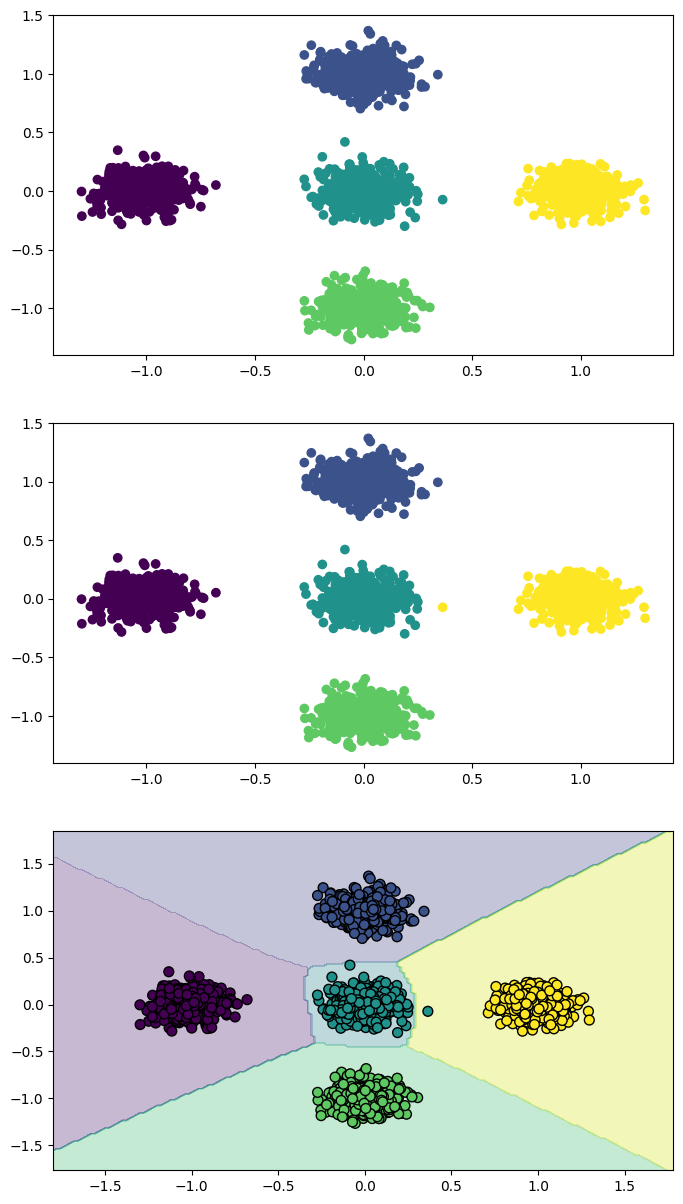

In [10]:
if config.finsler.use:

    X = torch.from_numpy(adata.obsm['X_pca']).float()
    y = torch.from_numpy(adata.obs['cell_type_one_hot'].astype(int).to_numpy()).long()
    y_pred = classifier_model(X, normalize=True).argmax(dim=1)

    fig, axs = plt.subplots(3, figsize = (8,15))
    axs[0].scatter(X[:,0], X[:, 1], c=y)
    axs[1].scatter(X[:,0], X[:, 1], c=y_pred)
    
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.02  # Step size for the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.FloatTensor(grid_points)

    with torch.no_grad():
        logits = classifier_model(grid_tensor, normalize=True)
        predictions = torch.argmax(logits, dim=1)

    Z = predictions.cpu().numpy().reshape(xx.shape)
    
    axs[2].contourf(xx, yy, Z, alpha=0.3, cmap='viridis')    
    scatter = axs[2].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k', s=50)

    plt.show()
    

In [11]:
from torch.utils.data import TensorDataset, Sampler, DataLoader
from datasets.dataset import *

dataset = extract_paired_dataset(adata_train)
train_dataset = ShufflingDataset(dataset, 20)
train_dataloader = DataLoader(train_dataset, batch_size = config.loader_batch_size, shuffle=True)

cpu


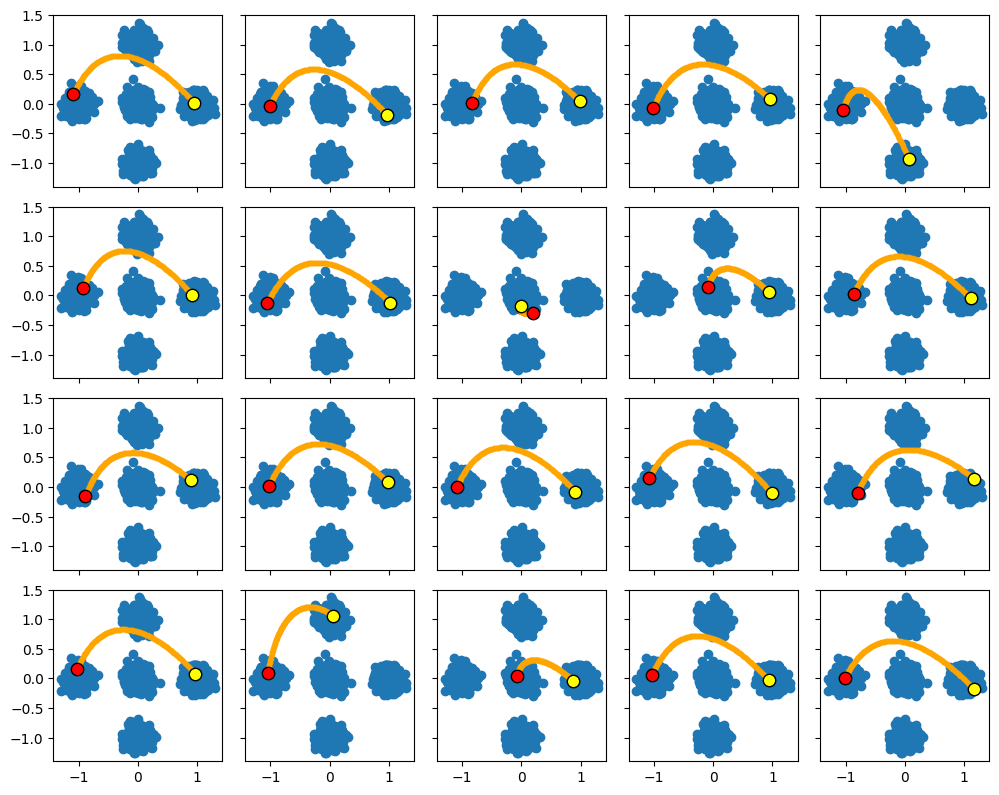

In [12]:
#GEO VALIDATION
for batch in train_dataloader:

    x0, x1, t0, t1 = batch
    print(x0.device)
    
    paths = embed_model.sample_geodesic_path(batch, num_points=200, ot_sample=False)

    break

fig, ax = plt.subplots(4, 5, figsize=(10, 8), sharex=True, sharey=True)

ax = ax.flatten()

for i in range(20):
    traj = paths[:,i]
    ax[i].scatter(samples[:,0], samples[:, 1])
    ax[i].plot(traj[:, 0], traj[:, 1], marker=".", linestyle="-", alpha=0.7, lw=1.5, color='orange')
    ax[i].scatter(traj[0, 0], traj[0, 1], s=80, marker="o", color="red", edgecolor="black", zorder=3)
    ax[i].scatter(traj[-1, 0], traj[-1, 1], s=80, marker="o", color="yellow", edgecolor="black", zorder=3)

    ax[i].set(adjustable='box', aspect='equal')

plt.tight_layout() # Optional: adjusts spacing so labels don't overlap
plt.show()

/home/azweig/projects/finfm/models/embed_models.py:138: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(j)


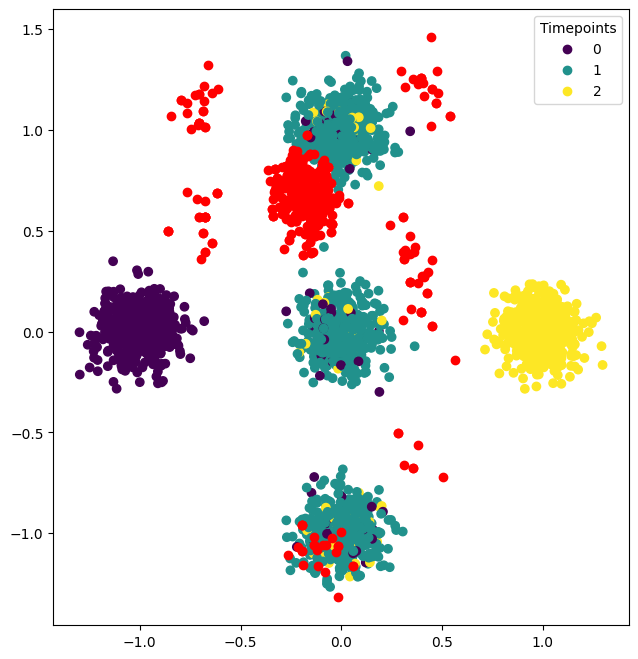

In [13]:
#GEO INTERPOLATION VALIDATION

t0, t1 = timepoints[config.t0_index], timepoints[config.t1_index]
t = (t0+t1) // 2

adata_prune = adata[adata.obs['timepoint'].isin([t0, t1])]
dataset = extract_paired_dataset(adata_prune)
train_dataset = ShufflingDataset(dataset, 512)
train_dataloader = DataLoader(train_dataset, batch_size = 1)

batch = next(iter(train_dataloader))
samples, weights = embed_model.sample_geodesic_time(batch, t, weighted = True)
weights = torch.softmax(weights, dim=0)
#TODO: weight?

true = torch.from_numpy(adata.obsm['X_pca']).float()
fig, axs = plt.subplots(1, figsize = (15, 8))
scatter0 = axs.scatter(true[:,0], true[:, 1], c=adata.obs['timepoint'].astype(int).tolist())
handles, labels = scatter0.legend_elements()
axs.legend(handles, labels, title="Timepoints")
axs.scatter(samples[:,0], samples[:,1], c="red")
axs.set_aspect('equal')

plt.show()

torch.Size([200, 512, 2]) torch.Size([200, 512])
torch.Size([512])


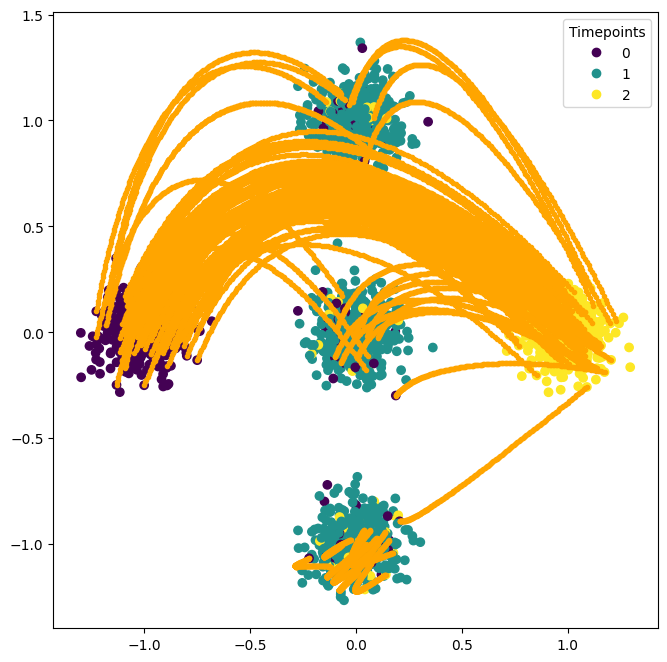

In [14]:
adata_prune = adata[adata.obs['timepoint'].isin([t0, t1])]
dataset = extract_paired_dataset(adata_prune)
train_dataset = ShufflingDataset(dataset, 512)
train_dataloader = DataLoader(train_dataset, batch_size = 1)


batch = next(iter(train_dataloader))
paths, weights = embed_model.sample_geodesic_path(batch, num_points=200, weighted=True)
print(paths.shape, weights.shape)
weights = torch.max(weights, dim = 0)[0]
weights = torch.softmax(weights, dim = 0)
min_val = torch.min(weights)
max_val = torch.max(weights)
weights = (weights - min_val) / (max_val - min_val)
print(weights.shape)
if config.method == "exact":
        weights = torch.ones_like(weights)

samples = torch.from_numpy(adata.obsm['X_pca']).float()
fig, axs = plt.subplots(1, figsize = (15, 8))
scatter0 = axs.scatter(samples[:,0], samples[:, 1], c=adata.obs['timepoint'].astype(int).tolist())
handles, labels = scatter0.legend_elements()
axs.legend(handles, labels, title="Timepoints")
for i in range(100):
        axs.plot(paths[:, i, 0], paths[:,i, 1], marker=".", linestyle="-", alpha=weights[i].item(), lw=1.5, color='orange')
axs.set_aspect('equal')

plt.show()